### Olaleye Ayomide Samuel
## Data Analysis

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
print('Done')

Done


## importing my dataset

In [2]:
df=pd.read_csv('SampleSuperStore.csv')
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [3]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
print(df.shape)
print('')
print(df.dtypes)
print('')
print(df.info())


(9994, 13)

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int

In [5]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [6]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [7]:
df.describe()
#statistics for numerical columns

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Unique Value Analysis

In [8]:
#Categoties
print(df['Category'].value_counts())

print('')

print(df['Sub-Category'].value_counts())
print('')

print(df['State'].value_counts())
print('')

print(df['City'].value_counts())

print('')

print(df['State'].nunique())
print('')
print(df['City'].nunique())
print('')
print(df.City.unique())
print('')
print(df.State.unique())
print('')
print(df.Region.unique())


Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

State
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     469
Florida                  383
Michigan                 255
North Carolina           249
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts

### Check Sub-Category under each category

In [9]:
df.groupby('Category')['Sub-Category'].unique()

Category
Furniture                   [Bookcases, Chairs, Tables, Furnishings]
Office Supplies    [Labels, Storage, Art, Binders, Appliances, Pa...
Technology                  [Phones, Accessories, Machines, Copiers]
Name: Sub-Category, dtype: object

In [10]:
for category in df['Category'].unique():
    print(f'{category}')
    print(df[df['Category']==category]['Sub-Category'].unique())

Furniture
['Bookcases' 'Chairs' 'Tables' 'Furnishings']
Office Supplies
['Labels' 'Storage' 'Art' 'Binders' 'Appliances' 'Paper' 'Envelopes'
 'Fasteners' 'Supplies']
Technology
['Phones' 'Accessories' 'Machines' 'Copiers']


### Relationship Analysis

## Categorical Analysis

## First Relationship
## Sales and profit by category

In [11]:
df.groupby('Category')[['Sales','Profit']].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


## Second Relationship
## Discount and Sales by category
## Discount and profit by category

In [12]:
print(df.groupby('Category')[['Discount','Sales']].sum())
print('')
print(df.groupby('Category')[['Discount','Profit']].sum())

                 Discount        Sales
Category                              
Furniture          368.89  741999.7953
Office Supplies    947.80  719047.0320
Technology         244.40  836154.0330

                 Discount       Profit
Category                              
Furniture          368.89   18451.2728
Office Supplies    947.80  122490.8008
Technology         244.40  145454.9481


## Third Relationship
## Quantity, sales and profit by category

In [13]:
df.groupby('Category')[['Quantity','Sales','Profit']].sum()

,Quantity,Sales,Profit
Category,,,
Furniture,8028,741999.7953,18451.2728
Office Supplies,22906,719047.0320,122490.8008
Technology,6939,836154.0330,145454.9481


## All relationship
## sales, profit, quantity, discount by category

In [14]:
df.groupby('Category')[['Sales','Profit','Quantity','Discount']].sum()

,Sales,Profit,Quantity,Discount
Category,,,,
Furniture,741999.7953,18451.2728,8028,368.89
Office Supplies,719047.0320,122490.8008,22906,947.80
Technology,836154.0330,145454.9481,6939,244.40


## Regional Analysis

In [15]:
df.groupby('Region')[['Sales','Profit','Quantity','Discount']].sum()

,Sales,Profit,Quantity,Discount
Region,,,,
Central,501239.8908,39706.3625,8780,558.34
East,678781.2400,91522.7800,10618,414.00
South,391721.9050,46749.4303,6209,238.55
West,725457.8245,108418.4489,12266,350.20


## Category by Region


In [16]:
df.groupby(['Category', 'Region'])[['Sales','Profit','Quantity','Discount']].sum()

Sales      Profit  Quantity  Discount
Category        Region                                              
Furniture       Central  163797.1638  -2871.0494      1827    143.04
                East     208291.2040   3046.1658      2214     92.60
                South    117298.6840   6771.2061      1291     40.35
                West     252612.7435  11504.9503      2696     92.90
Office Supplies Central  167026.4150   8879.9799      5409    359.40
                East     205516.0550  41014.5791      6462    244.70
                South    125651.3130  19986.3928      3800    166.60
                West     220853.2490  52609.8490      7235    177.10
Technology      Central  170416.3120  33697.4320      1544     55.90
                East     264973.9810  47462.0351      1942     76.70
                South    148771.9080  19991.8314      1118     31.60
                West     251991.8320  44303.6496      2335     80.20

## Sub-Category Investigation

## Furniture investigation


In [17]:
df[df['Category']== 'Furniture'].groupby('Sub-Category')[['Sales', 'Profit', 'Discount', 'Quantity']].sum()

,Sales,Profit,Discount,Quantity
Sub-Category,,,,
Bookcases,114879.9963,-3472.5560,48.14,868
Chairs,328449.1030,26590.1663,105.00,2356
Furnishings,91705.1640,13059.1436,132.40,3563
Tables,206965.5320,-17725.4811,83.35,1241


In [18]:
df[df['Category']== 'Office Supplies'].groupby('Sub-Category')[['Sales', 'Profit', 'Discount', 'Quantity']].sum()

,Sales,Profit,Discount,Quantity
Sub-Category,,,,
Appliances,107532.161,18138.0054,77.6,1729
Art,27118.792,6527.7870,59.6,3000
Binders,203412.733,30221.7633,567.0,5974
Envelopes,16476.402,6964.1767,20.4,906
Fasteners,3024.280,949.5182,17.8,914
Labels,12486.312,5546.2540,25.0,1400
Paper,78479.206,34053.5693,102.6,5178
Storage,223843.608,21278.8264,63.2,3158
Supplies,46673.538,-1189.0995,14.6,647


In [19]:
df[df['Category']== 'Technology'].groupby('Sub-Category')[['Sales', 'Profit', 'Discount', 'Quantity']].sum()

,Sales,Profit,Discount,Quantity
Sub-Category,,,,
Accessories,167380.318,41936.6357,60.8,2976
Copiers,149528.030,55617.8249,11.0,234
Machines,189238.631,3384.7569,35.2,440
Phones,330007.054,44515.7306,137.4,3289


## Explorative Data Analysis

## Total Sales by Category

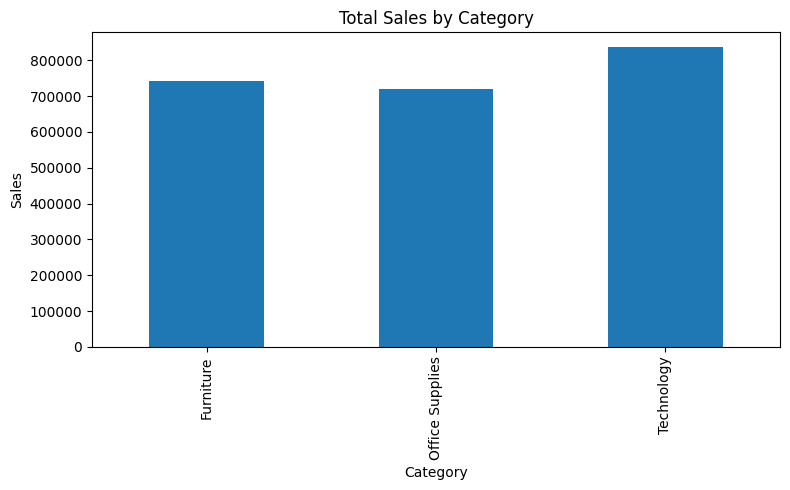

In [20]:
Category_Sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))

Category_Sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

## Observation

### Technolgy generated the highest number of sales among all categories, followed by Furniture and office suplies.

## profit by Category

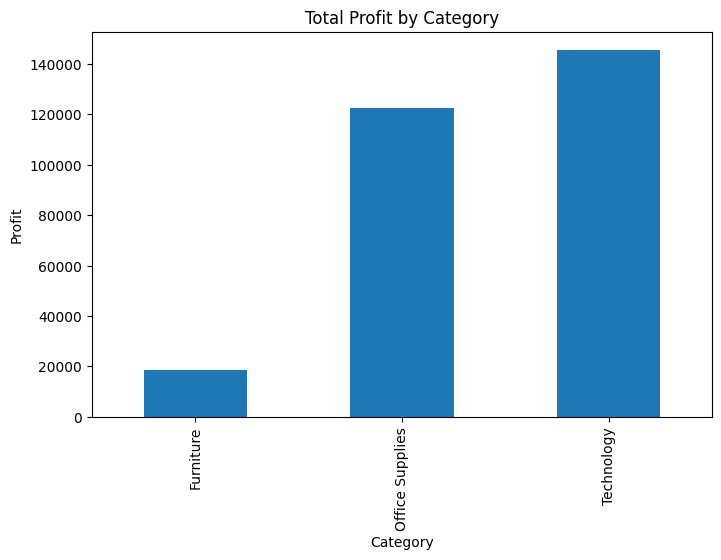

In [21]:
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()


### Technology generated the highest profit, followed by Office supplies and furniture

## Asproven in the previous analysis
### .Technology generated the highest sales and profit in category section indicating a direct proportionality in sales and profit. 
### .Furniture generated the seconf highest sales but made the lowest profit. This indicates several underlying facctors. 
### .Office supplies generated the lowest sales but made the seconf highest profit. This indicates several underlying factors. 

### The difference in profit between FURNITURE and OFFICE SUPPLIES is a very WIDE margin relative to the sales made.


## Discount by Profit

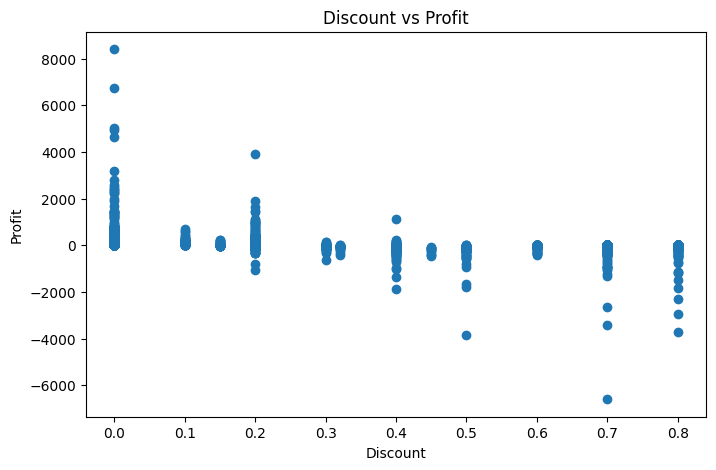

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(df["Discount"], df["Profit"])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

## Discount vs Profit (Scatter Plot)
### This shows how discount levels affect profit: At 0% discount, profit is highest and most variable (up to ~8,500) As discounts increase from 0.3 to 0.8, profits increasingly turn negative Heavy discounts (0.7–0.8) almost exclusively result in losses Clear takeaway: higher discounts strongly correlate with lower or negative profit

## Sales by Profit

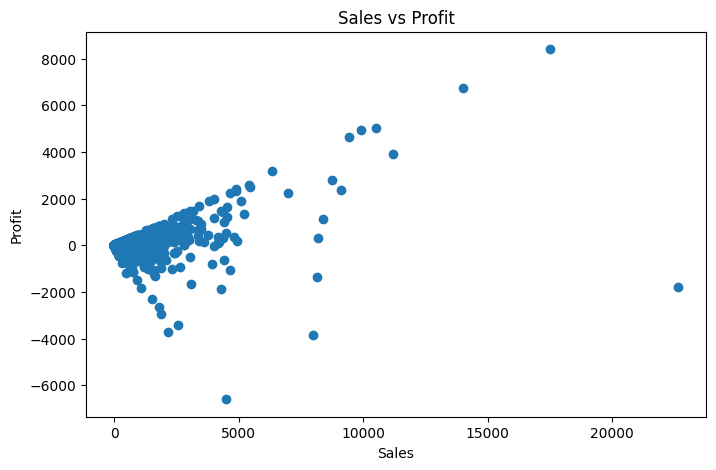

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()


###  Sales vs Profit (Scatter Plot) 

### This chart shows the relationship between sales amount and profit earned: Most transactions cluster between 0–5,000 in sales, with profits ranging from about -4,000 to +2,500 As sales increase beyond 10,000, profits generally trend upward — the highest profits (~8,500) appear near the 17,000–18,000 sales range However, there are notable outliers with losses (negative profit) even at higher sales values, suggesting discounts or high costs can erode profit regardless of revenue Overall, there's a weak positive correlation — higher sales tend to produce higher profit, but it's not guaranteed

## profit Distrbution Histogram

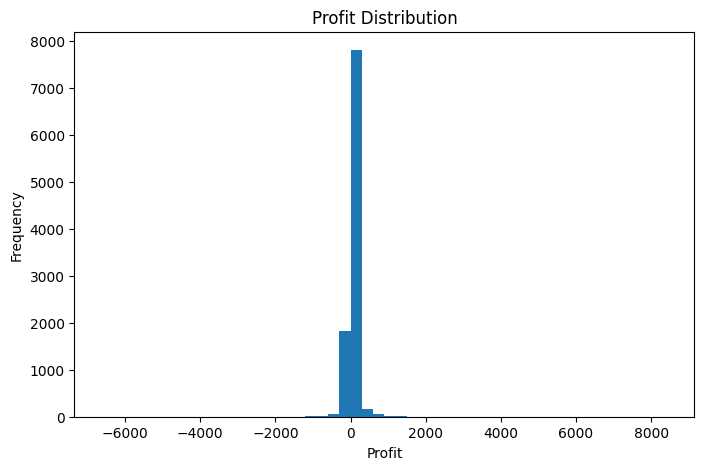

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=50)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

### Profit Distribution (Histogram) This shows how profit values are spread across all transactions: The vast majority of transactions cluster just around 0 to slightly positive profit — the tallest bar (~7,800 frequency) sits right at that point Very few transactions result in large profits or large losses The distribution is heavily right-skewed (long tail to the right), meaning most sales make small profits, but a few make very large ones Losses (negative profit) do occur but are far less frequent than gains Key insight: Most individual transactions are low-profit; big profits are rare exceptions

## Correlation heatmap

## Category Profitability Bar Chart

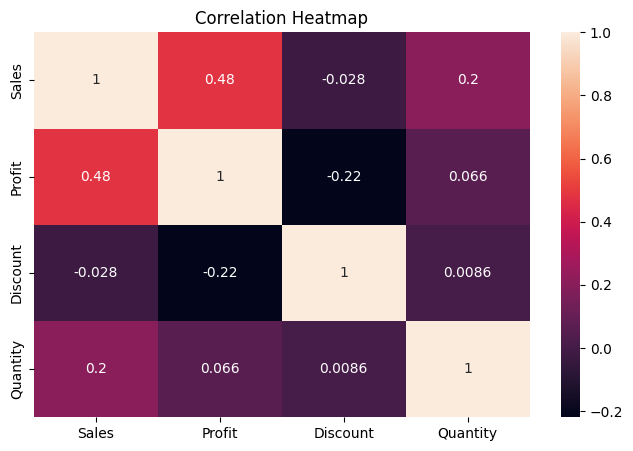

In [29]:
correlation = df[["Sales", "Profit", "Discount", "Quantity"]].corr()

plt.figure(figsize=(8,5))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

### Shows how strongly pairs of variables relate to each other (scale: -1 to +1): Pair Value Meaning Sales ↔ Profit 0.48 Moderate positive — more sales tends to mean more profit Sales ↔ Discount -0.028 Almost no relationship Profit ↔ Discount -0.22 Weak negative — higher discounts slightly reduce profit Sales ↔ Quantity 0.2 Weak positive Profit ↔ Quantity 0.066 Nearly no relationship Strongest relationship: Sales and Profit (0.48) Most damaging: Discount hurts Profit (-0.22)

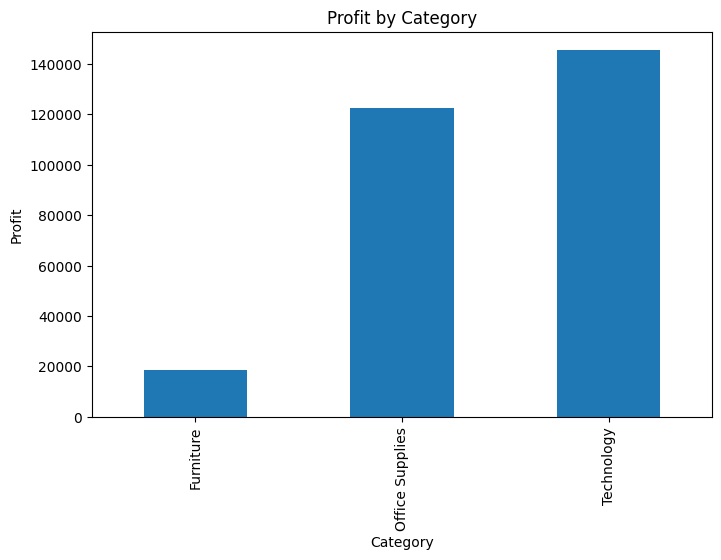

In [30]:
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

## Regional Profit Analysis

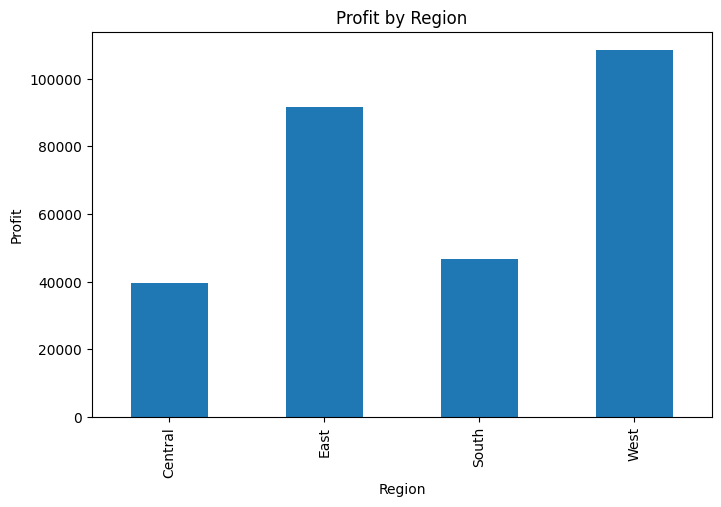

In [31]:
region_profit = df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(8,5))

region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

### West again leads with 110,000 profit East is second at 92,000 South comes third at ~47,000 Central is the weakest at ~$40,000 Notable: Central has higher sales than South, but less profit — suggesting Central has worse profit margins, possibly due to higher discounts or costs

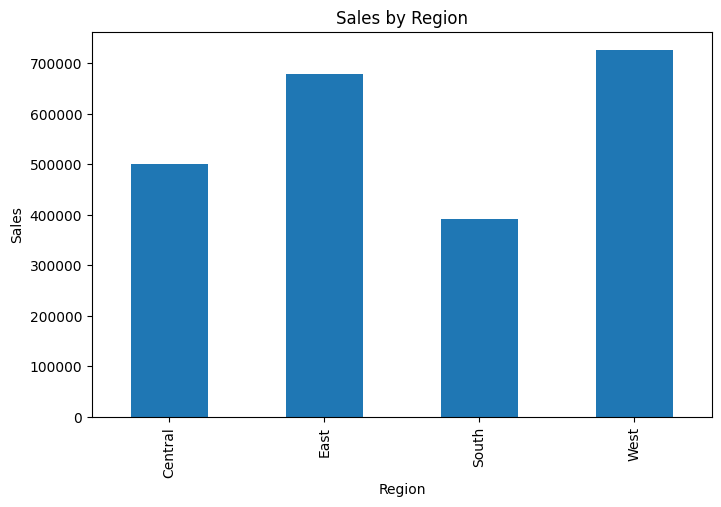

In [35]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

### West leads with ~725,000 in sales East is second at ~675,000 Central is third at ~500,000 South is lowest at ~390,000 West and East together dominate total revenue

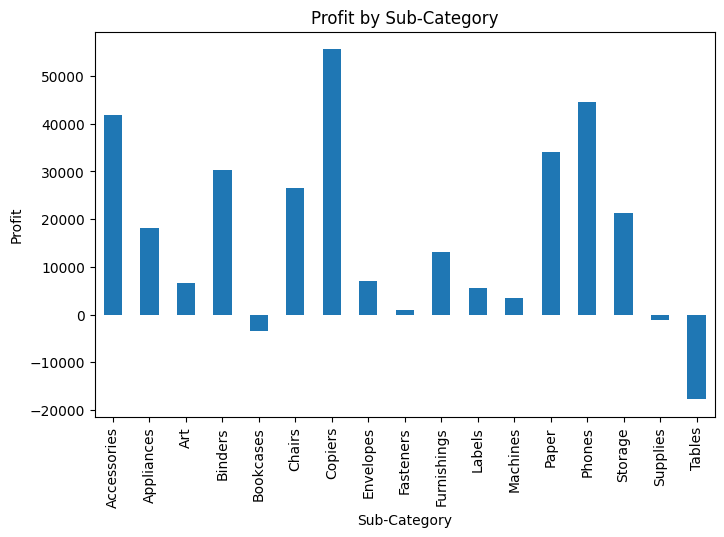

In [34]:
profit_subcategory = df.groupby("Sub-Category")["Profit"].sum()

plt.figure(figsize=(8,5))

profit_subcategory.plot(kind="bar")

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.show()